# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
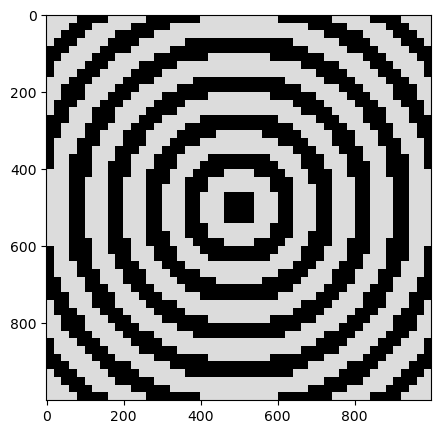


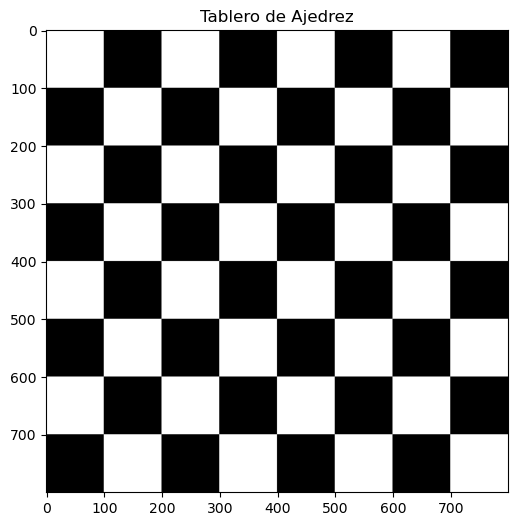

In [83]:
import numpy as np
import matplotlib.pyplot as plt

casilla = 100
filas = 8
columnas = 8
tamano_x = columnas * casilla
tamano_y = filas * casilla

imagen = np.ones((tamano_y, tamano_x), dtype=np.uint8) * 255

for fila in range(filas):
    for col in range(columnas):
        # Calculamos donde empieza y termina cada casilla en pixeles
        y_ini = fila * casilla
        y_fin = y_ini + casilla
        x_ini = col * casilla
        x_fin = x_ini + casilla
        
        if (fila + col) % 2 != 0:
            imagen[y_ini:y_fin, x_ini:x_fin] = 0

plt.figure(figsize=(6,6))
plt.imshow(imagen, cmap='gray')
plt.title("Tablero de Ajedrez")
plt.show()


# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
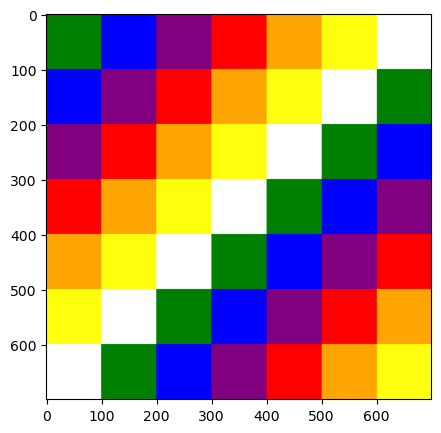

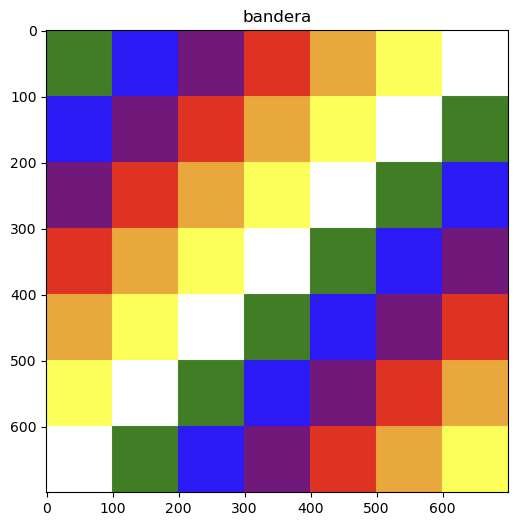

In [27]:
import numpy as np
import matplotlib.pyplot as plt

casilla = 100
filas = 7
columnas = 7

tamano_x = columnas * casilla
tamano_y = filas * casilla
imagen = np.zeros((tamano_y, tamano_x, 3), dtype=np.uint8)

colores = [
    [64, 125, 36], 
    [44, 26, 244], 
    [113, 24, 123], 
    [222, 51, 35], 
    [233, 168, 62],
    [252, 254, 89], 
    [255, 255, 255]
]

for fila in range(filas):
    for col in range(columnas):
        y_ini = fila * casilla
        y_fin = y_ini + casilla
        x_ini = col * casilla
        x_fin = x_ini + casilla
     
        color_idx = (fila + col) % len(colores)
        imagen[y_ini:y_fin, x_ini:x_fin] = colores[color_idx]

plt.figure(figsize=(6,6))
plt.imshow(imagen)
plt.title("bandera")
plt.show()

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

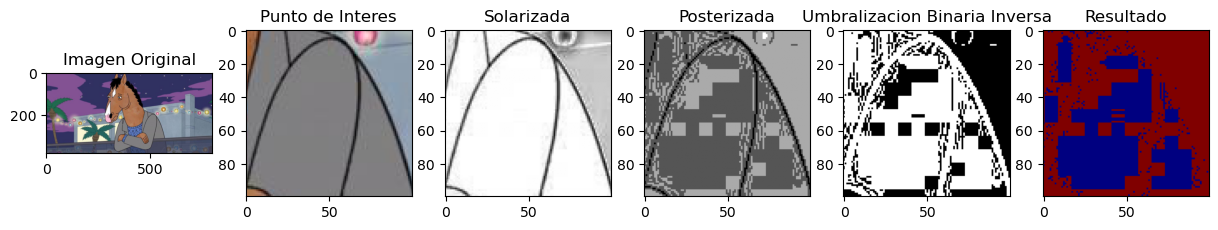

True

In [84]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import random

def posterizar(imagen,niveles):
    factor_escala=255/niveles
    img_pos=np.round(imagen/factor_escala)*factor_escala
    return img_pos.astype(np.uint8)

def solarizar(imagen, umbral):
    imagen_sol = np.where(imagen < umbral, imagen, 255 - imagen)
    return imagen_sol



img = cv2.imread('imagen1.jpg')
alto, ancho, _ = img.shape

x = random.randint(0, ancho - 100)
y = random.randint(0, alto - 100)
img_recortada = img[y:y+100, x:x+100]

img_gray=cv2.cvtColor(img_recortada, cv2.COLOR_BGR2GRAY) 

umbral = 127 
img_fin=solarizar(img_gray, umbral) 

nvl=3
img_fin2=posterizar(img_gray, nvl)


umbral = 127 
result1=solarizar(img_gray, umbral) 

nvl=3
result2=posterizar(result1, nvl)

# Umbralizacion Binaria Inversa
_,umbral_binaria_inv=cv2.threshold(img_gray,127,255,cv2.THRESH_BINARY_INV)

_,result_fin=cv2.threshold(result2,127,255,cv2.THRESH_BINARY_INV)



def falso_color(img_gray):
    escal_img=cv2.normalize(img_gray,None,0,255,cv2.NORM_MINMAX)
    falso_img=cv2.applyColorMap(escal_img,cv2.COLORMAP_JET)
    return falso_img

result_fin2=falso_color(result_fin)   


plt.figure(figsize=(15, 10))

plt.subplot(1, 6, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(1, 6, 2)
plt.title('Punto de Interes')
plt.imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))
 
plt.subplot(1, 6, 3)
plt.title('Solarizada')
plt.imshow(img_fin, cmap='gray')  

plt.subplot(1, 6, 4)
plt.title('Posterizada')
plt.imshow(img_fin2, cmap='gray')

plt.subplot(1,6,5)
plt.imshow(umbral_binaria_inv,cmap='gray')
plt.title('Umbralizacion Binaria Inversa')

plt.subplot(1,6,6)
plt.imshow(cv2.cvtColor(result_fin2, cv2.COLOR_BGR2RGB))
plt.title('Resultado')

plt.show()


cv2.imwrite('Punto de interes.jpg', img_recortada)
cv2.imwrite('Solarizada.jpg', img_fin)
cv2.imwrite('Posterizada.jpg', img_fin2)
cv2.imwrite('Umbralizacion binaria inversa.jpg', umbral_binaria_inv)
cv2.imwrite('resultado final.jpg', result_fin2)


# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

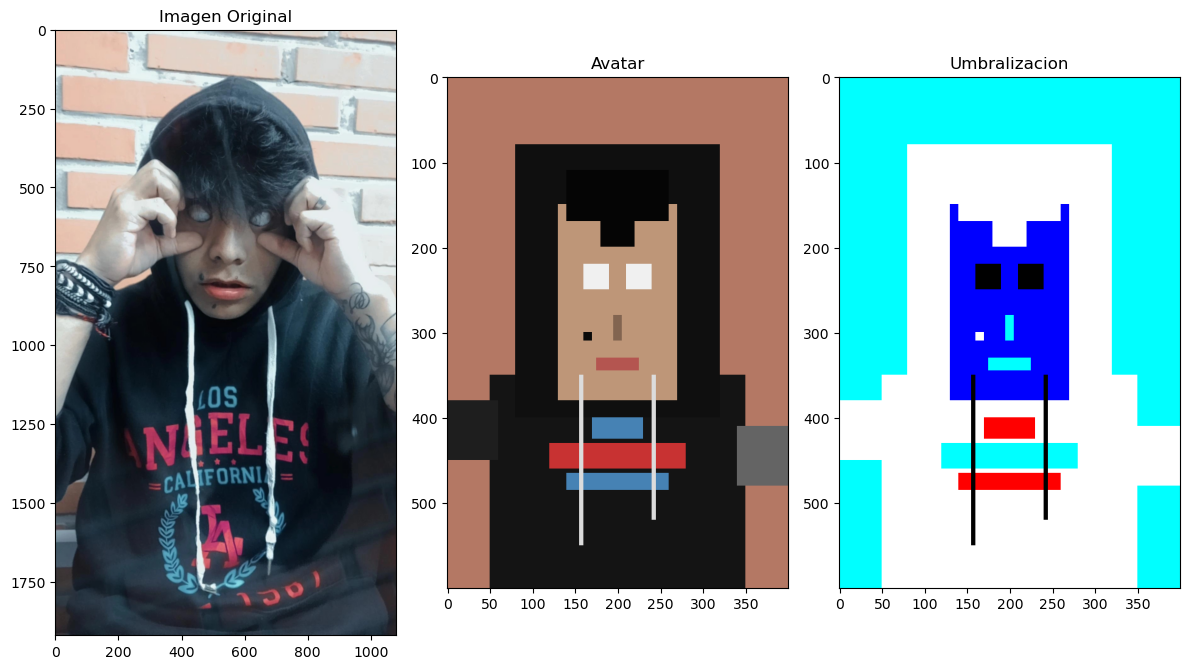

In [87]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img = np.zeros((600, 400, 3), dtype=np.uint8)

img[:, :] = [100, 120, 180] 

img[350:600, 50:350] = [20, 20, 20] 

img[80:400, 80:320] = [15, 15, 15]

img[150:380, 130:270] = [120, 150, 190] 
img[220:250, 160:190] = [240, 240, 240]
img[220:250, 210:240] = [240, 240, 240] 

img[280:310, 195:205] = [80, 100, 130] 
img[330:345, 175:225] = [80, 85, 180]   
img[300:310, 160:170] = [10, 10, 10]   
img[110:170, 140:260] = [5, 5, 5]
img[140:200, 180:220] = [5, 5, 5] 

img[430:460, 120:280] = [50, 50, 200] 

img[400:425, 170:230] = [180, 130, 70] 
img[465:485, 140:260] = [180, 130, 70] 


img[350:550, 155:160] = [220, 220, 220]
img[350:520, 240:245] = [220, 220, 220]

img[380:450, 0:60] = [30, 30, 30] 
img[410:480, 340:400] = [100, 100, 100]

cv2.imwrite("avatar.jpg", img)



img_yo = cv2.imread('yo.png')


# Umbralizacion Binaria Inversa
_,umbral_binaria_inv=cv2.threshold(img,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12, 8))


plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img_yo, cv2.COLOR_BGR2RGB))

plt.subplot(1, 3, 2)
plt.title("Avatar")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.subplot(1, 3, 3)
plt.title("Umbralizacion")
plt.imshow(cv2.cvtColor(umbral_binaria_inv, cv2.COLOR_BGR2RGB))

plt.tight_layout()
plt.show()